---
authors: Freek Pols
updated: December 3, 2025
---

# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

***Ruwe Data***

In [67]:
#importing necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#importing and labeling data

data = np.loadtxt(r'C:\Users\tahli\Downloads\tempmetingen-e531a4a7a0f586ef072944895e84158f.csv', delimiter = ';', skiprows = 1)

t = data[:,0] * 60      #seconds

T = data[:,1] + 273.15     #Kelvin
T_0 = T[0]                 #Kelvin

mb = 820.8         #grams
m1 = 1292.9 - mb   #grams
m2 = 1274.9 - mb   #grams
m_evap = m1-m2     #grams

c = 4.18           #Joules / gram * Kelvin
h = 2257           #Joules / gram

***Deel 1*** plotten

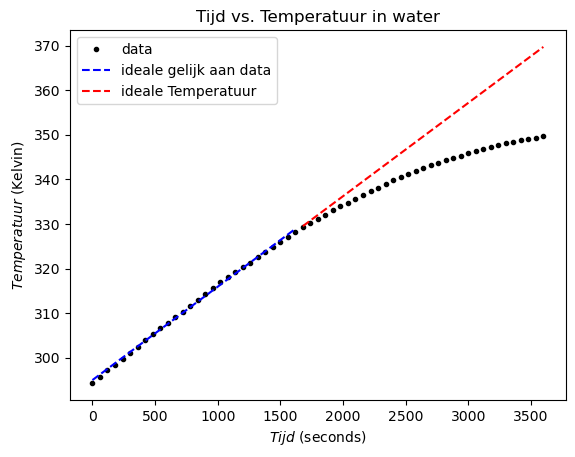

In [65]:
#plotting data

plt.plot(t, T, 'k.', label = 'data')
plt.xlabel('$Tijd$ (seconds)')
plt.ylabel('$Temperatuur$ (Kelvin)')
plt.title('Tijd vs. Temperatuur in water')

#creating a curve fit for the linear part

liquid = T <= 329.15
t1 = t[liquid]
T1 = T[liquid]
t2 = t[T > 329.15]
T2 = T[T > 329.15]

def func(t1, a, b):
    return a * t1 + b

popt, pcov = curve_fit(func, t1, T1)

a = popt[0]
b = popt[1]

plt.plot(t1, func(t1, a, b), 'b--', label = 'ideale gelijk aan data')


#creating a curve fit for when the water starts to boil

P = a * m1 * c              #Power
T_curve = T_0 + a * t2

plt.plot(t2, T_curve, 'r--', label = 'ideale Temperatuur')

plt.legend()
plt.show()

***Deel 2*** Energie

In [66]:
#comparing heat put into the system and used by the system

Q_used = m1 * c * (T[-1] - T_0) + m_evap * h

Q_in = P * t[-1]


if Q_in > Q_used:
    print('The amount of heat put into the system is more than the system used')
else:
    print('The amount of heat the system used is more than what was put into the system')


The amount of heat the system used is more than what was put into the system


***Deel 3*** Uitleg

Als dit experiment nog een keer gedaan zou worden, denk ik dat er meer rekening met de omgeving temperatuur moet gehouden worden. ook het materiaal van de beker. Wanneer de beker geen gooie insulator is, ontsnapt heel veel hitte, Q, en daarvoor energie. Dat is de grootste reden waarom wij een buig in onze data hebben. Nog een reden dat onze data geen rechte lijn is, is omdat het water verdamt na een bepaalde hitte bereikt word. Door deze verdamping hoeven we minder mass op te heten, en omdat temperatuur een intensieve eigenschap is, na een vermindering van massa verwarmt het water per seconde sneller op. 